In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import seaborn as sns
import matplotlib.pyplot as plt

# Set global Seaborn style
sns.set_theme(
    style='whitegrid',
    context='paper',
    font='DejaVu Sans',
)

%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from common.consts import res_colors, long_to_short
from common.utils import load_lambda_grid, short_to_residue

data_dir = repo_root / 'data'
mfpt_grid_pkl = data_dir / 'mfpt_all_thresholds-new-ref.pkl'
mfpt_default_pkl = data_dir / 'mfpt-pace=25000-new-ref.pkl'
lambda_cache = data_dir / 'hlda_lambda_grid.pkl'

with open(mfpt_grid_pkl, 'rb') as f:
    mfpt_tables = pickle.load(f)
mfpt_thresholds = sorted(mfpt_tables.keys())

with open(mfpt_default_pkl, 'rb') as f:
    mfpt_all = pickle.load(f)

skip_short = {}


In [10]:
lambda_grid = load_lambda_grid(cache_path=lambda_cache)
if 'res_weights' not in lambda_grid.columns:
    raise ValueError('Missing res_weights in hlda_lambda_grid.pkl; rebuild with weights.')

wt_grid = lambda_grid[lambda_grid['Mutant'] == 'WT']
if wt_grid.empty:
    raise ValueError('WT not found in hlda_lambda_grid.pkl')

# filter skip list from MFPT tables
mfpt_all = {k: v for k, v in mfpt_all.items() if long_to_short.get(k) not in skip_short}


In [11]:
def mfpt_table_to_log_ratio(df_raw: pd.DataFrame) -> pd.DataFrame:
    if 'Mutant' not in df_raw.columns:
        df = df_raw.rename_axis('Mutant').reset_index()
    else:
        df = df_raw.copy()
    df['Mutant'] = df['Mutant'].astype(str).str.strip()
    df['MFPT'] = pd.to_numeric(df['mfpt'], errors='coerce') / 1e6
    wt_val = df.loc[df['Mutant'] == 'WT', 'MFPT'].iloc[0]
    df['log_mfpt_ratio'] = np.log(wt_val / df['MFPT'])
    df['short'] = df['Mutant'].map(long_to_short).fillna(df['Mutant'])
    df['residue_idx'] = df['short'].map(short_to_residue)
    return df[['short', 'residue_idx', 'log_mfpt_ratio']]

def mean_ratio_vs_wt_weights(tF: float, tU: float, thr) -> pd.DataFrame:
    wt_row = wt_grid[(wt_grid['tF'] == tF) & (wt_grid['tU'] == tU)]
    if wt_row.empty:
        return pd.DataFrame()
    res_weights = wt_row.iloc[0]['res_weights']
    df_ratio = mfpt_table_to_log_ratio(mfpt_tables[thr])
    df_ratio = df_ratio[df_ratio['short'].apply(lambda s: s not in skip_short)]
    mean_df = df_ratio.dropna(subset=['residue_idx']).groupby('residue_idx')[['log_mfpt_ratio']].mean().reset_index()
    mean_df['wt_res_weight'] = mean_df['residue_idx'].apply(lambda i: res_weights[int(i)] if int(i) < len(res_weights) else np.nan)
    return mean_df


In [12]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap='YlOrRd'):
    P = df.pivot(index='tF', columns='tU', values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading='flat'
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha='center', va='center', fontsize=6)

    ax.set_xlabel('tU')
    ax.set_ylabel('tF')
    ax.set_title(title, fontsize=9)
    return im


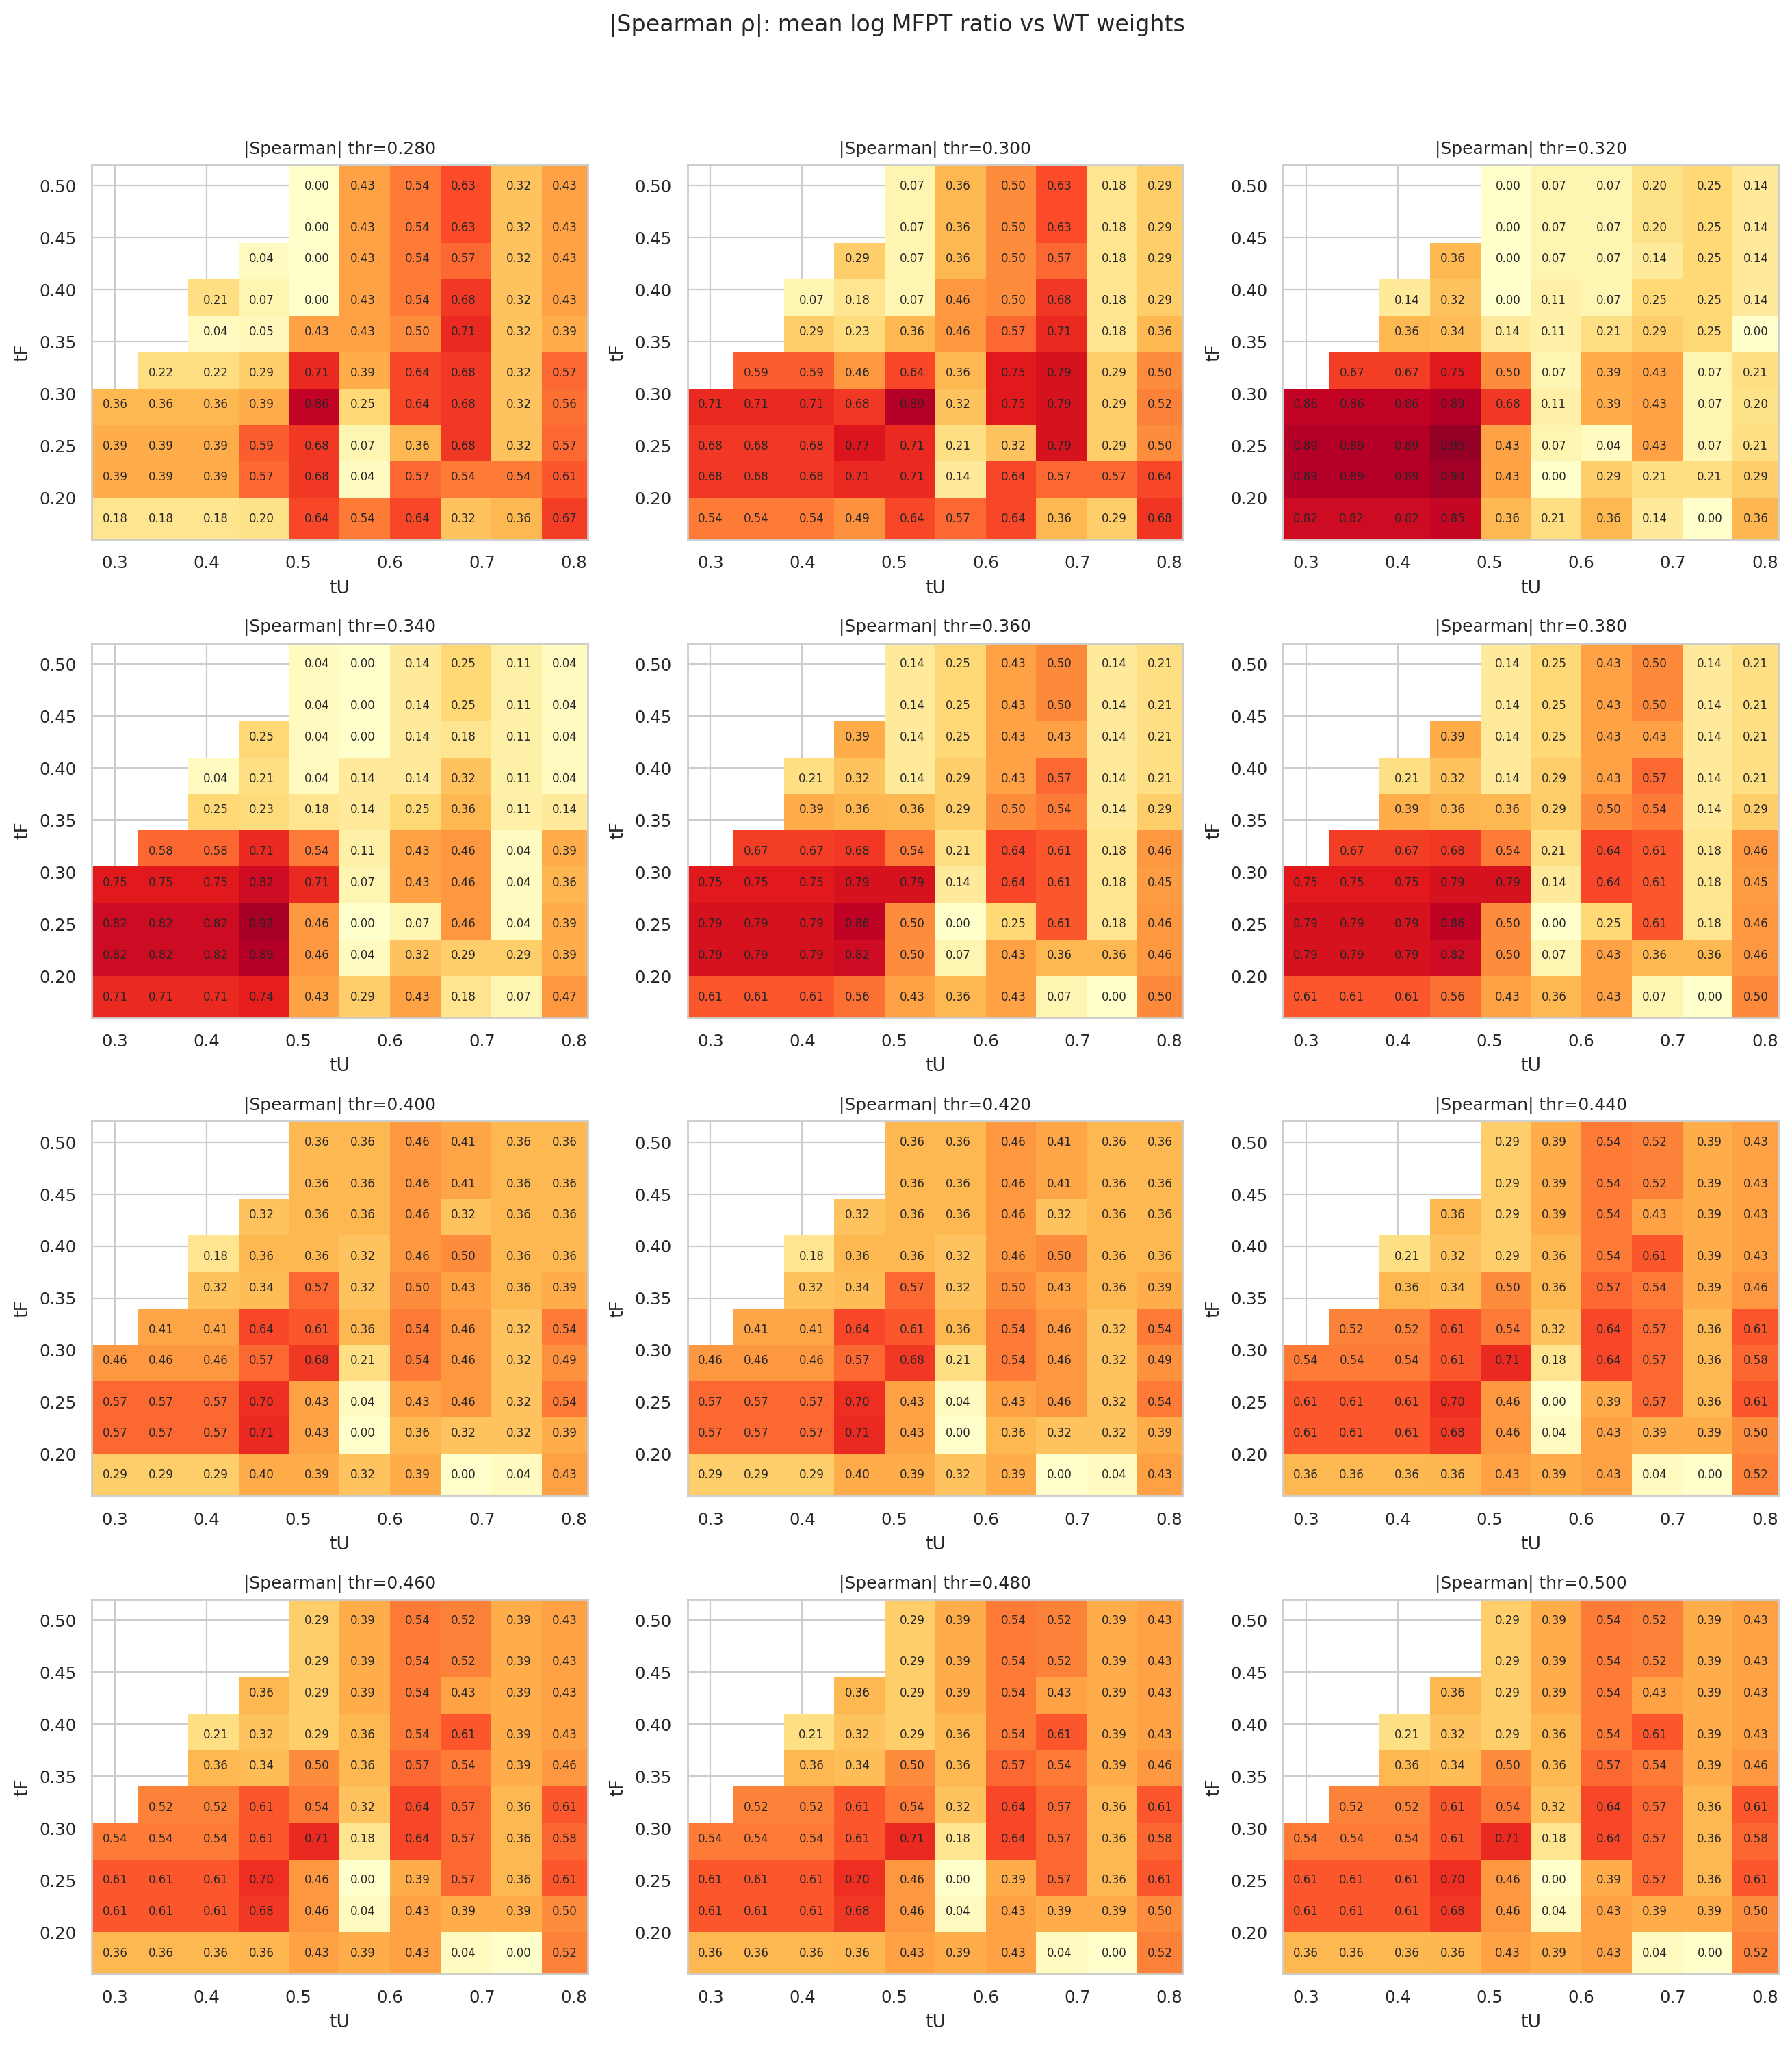

In [13]:
# Heatmaps: per-residue mean log MFPT ratio vs WT residue weights (Spearman)
unique_tf = sorted(wt_grid['tF'].unique())
unique_tu = sorted(wt_grid['tU'].unique())

heatmap_wt_results = []
for thr in mfpt_thresholds:
    rows = []
    for tF in unique_tf:
        for tU in unique_tu:
            mean_df = mean_ratio_vs_wt_weights(tF, tU, thr)
            if mean_df.empty or len(mean_df) < 2:
                continue
            rho = mean_df['wt_res_weight'].corr(mean_df['log_mfpt_ratio'], method='spearman')
            rows.append({'tF': float(tF), 'tU': float(tU), 'val': abs(rho) if pd.notna(rho) else np.nan})
    heatmap_wt_results.append({'thr': float(thr), 'rows': rows})

ncols = min(3, len(heatmap_wt_results) if heatmap_wt_results else 1)
nrows = int(np.ceil(len(heatmap_wt_results) / ncols)) if heatmap_wt_results else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
for ax, res in zip(axes.ravel(), heatmap_wt_results):
    df = pd.DataFrame(res['rows'])
    if df.empty:
        ax.axis('off')
        continue
    plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['thr']:.3f}", vmin=0, vmax=1, cmap='YlOrRd')
for ax in axes.ravel()[len(heatmap_wt_results):]:
    ax.axis('off')
fig.suptitle('|Spearman ρ|: mean log MFPT ratio vs WT weights', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


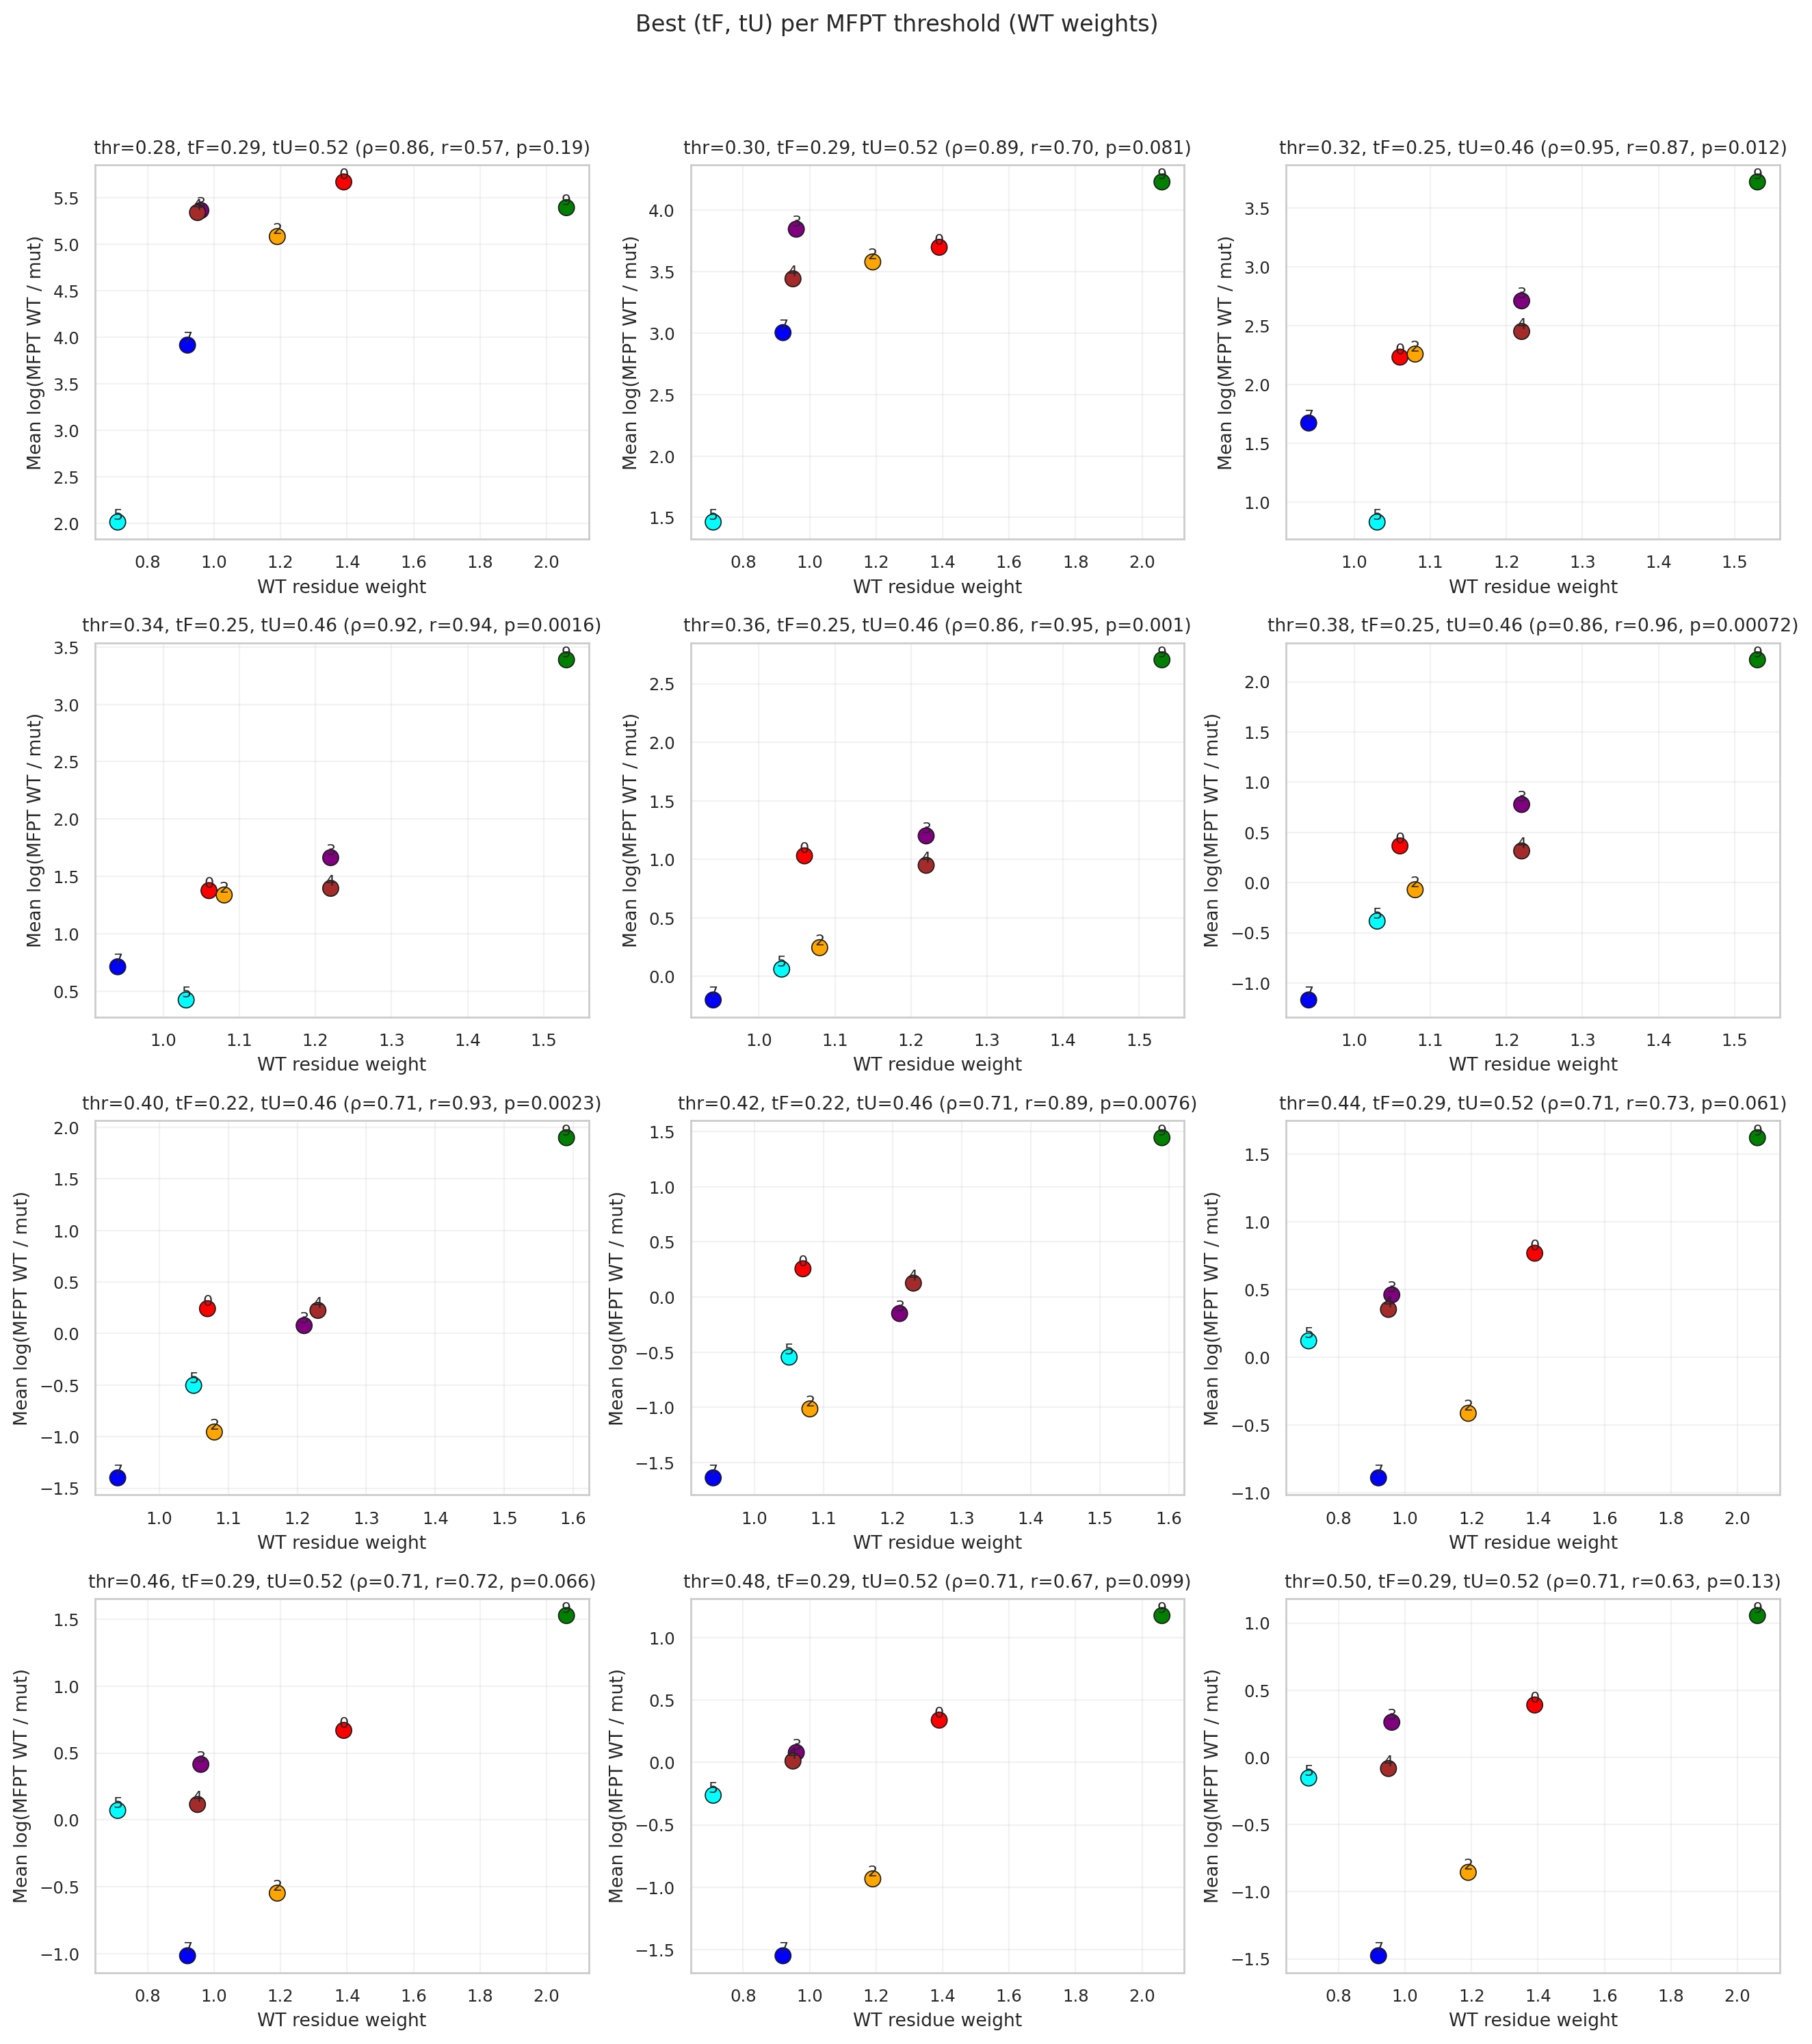

,thr,tF,tU,val
0,0.28,0.29,0.52,0.857143
1,0.30,0.29,0.52,0.892857
2,0.32,0.25,0.46,0.954994
3,0.34,0.25,0.46,0.918956
4,0.36,0.25,0.46,0.864900
5,0.38,0.25,0.46,0.864900
6,0.40,0.22,0.46,0.714286
7,0.42,0.22,0.46,0.714286
8,0.44,0.29,0.52,0.714286
9,0.46,0.29,0.52,0.714286


In [14]:
# Scatter plots at best (tF, tU) per MFPT threshold using WT weights
best_rows_wt = []
for res in heatmap_wt_results:
    df = pd.DataFrame(res['rows']).dropna(subset=['val'])
    if df.empty:
        continue
    idx = df['val'].idxmax()
    best = df.loc[idx]
    best_rows_wt.append({'thr': res['thr'], 'tF': best['tF'], 'tU': best['tU'], 'val': best['val']})

ncols = min(3, len(best_rows_wt) if best_rows_wt else 1)
nrows = int(np.ceil(len(best_rows_wt) / ncols)) if best_rows_wt else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)

for ax, b in zip(axes.ravel(), best_rows_wt):
    tF = float(b['tF'])
    tU = float(b['tU'])
    thr = float(b['thr'])
    mean_df = mean_ratio_vs_wt_weights(tF, tU, thr)
    colors = [res_colors.get(int(i), 'gray') for i in mean_df['residue_idx']]
    ax.scatter(mean_df['wt_res_weight'], mean_df['log_mfpt_ratio'], c=colors, s=70, edgecolor='k', linewidth=0.6)
    for _, row in mean_df.iterrows():
        ax.text(row['wt_res_weight'], row['log_mfpt_ratio'], str(int(row['residue_idx'])), fontsize=8, ha='center', va='bottom')
    rho = mean_df['wt_res_weight'].corr(mean_df['log_mfpt_ratio'], method='spearman')
    from scipy.stats import pearsonr
    r, p = pearsonr(mean_df['wt_res_weight'], mean_df['log_mfpt_ratio'])
    ax.set_title(f"thr={thr:.2f}, tF={tF:.2f}, tU={tU:.2f} (ρ={rho:.2f}, r={r:.2f}, p={p:.2g})")
    ax.set_xlabel('WT residue weight')
    ax.set_ylabel('Mean log(MFPT WT / mut)')
    ax.grid(True, alpha=0.25)

for ax in axes.ravel()[len(best_rows_wt):]:
    ax.axis('off')

fig.suptitle('Best (tF, tU) per MFPT threshold (WT weights)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

pd.DataFrame(best_rows_wt)
